# Notebook 04 — Spatial Typology: Phase 2

**Input**: `spatial/variable_characterization.csv` — 40 Band A–D variables × L6+L8 from the Phase 1 sweep.  
**Goal**: Assign each variable to a first-cut spatial typology group based on its profile in (I, scale-direction, outlier prevalence) space.  
**Output**: `spatial/first_cut_typology.csv` — variable, band, group, diagnostic values.

## Four proposed groups (from `prompts/SpatialESDA_Phase2.md`)

| Group | Signature |
|---|---|
| **continental-gradient** | High I, ↑ with resolution, LL-dominant or balanced |
| **network-topology** | Moderate I, ↓ with resolution, balanced HH/LL, non-zero LH |
| **local-anomaly** | Lower I, high outlier% (HL+LH) |
| **mixed** | Doesn't fit cleanly; flag for discussion |

Groups are exploratory and refinable. Variables near boundaries are flagged.

In [ ]:
# Cell 2
# %matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[2]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

REPO = Path.cwd().parents[2]
CSV_IN  = REPO / 'spatial' / 'variable_characterization.csv'
CSV_OUT = REPO / 'spatial' / 'first_cut_typology.csv'

print('Imports OK')
print(f'Input:  {CSV_IN}')
print(f'Output: {CSV_OUT}')

In [ ]:
# Cell 3
# Load and pivot to one row per variable
raw = pd.read_csv(CSV_IN)

l6 = raw[raw['scale'] == 'L6'].set_index('variable')
l8 = raw[raw['scale'] == 'L8'].set_index('variable')

df = pd.DataFrame({
    'schema_key':        l6['schema_key'],
    'friendly_name':     l6['friendly_name'],
    'band':              l6['band'],
    'I_L6':              l6['I_canonical'],
    'I_L8':              l8['I_canonical'],
    'delta_I':           l8['I_canonical'] - l6['I_canonical'],
    'log_transformed':   l6['log_transformed'],
    'skewness_L6':       l6['skewness'],
    'missing_pct_L6':    l6['missing_pct'],
    'cluster_core_L6':   l6['cluster_core_pct'],
    'outlier_pct_L6':    l6['outlier_pct'],
    'pct_HH_L6':         l6['pct_HH'],
    'pct_LL_L6':         l6['pct_LL'],
    'pct_LH_L6':         l6['pct_LH'],
    'pct_HL_L6':         l6['pct_HL'],
    'cluster_core_L8':   l8['cluster_core_pct'],
    'outlier_pct_L8':    l8['outlier_pct'],
})

# LL fraction of cluster core — 1.0 = all LL, 0.0 = all HH, 0.5 = balanced
df['LL_fraction'] = df['pct_LL_L6'] / df['cluster_core_L6'].replace(0, np.nan)
df['scale_dir'] = df['delta_I'].apply(lambda x: '↑' if x >= 0 else '↓')

print(f'{len(df)} variables loaded')
print(f'I_L6 range: {df["I_L6"].min():.3f} – {df["I_L6"].max():.3f}')
print(f'delta_I range: {df["delta_I"].min():.4f} – {df["delta_I"].max():.4f}')
print(f'\n{df[["band","I_L6","delta_I","outlier_pct_L6","scale_dir"]].sort_values("I_L6", ascending=False).to_string()}')

## Profile space: I_L6 vs Δ_I

The two primary axes:
- **x**: I_canonical at L6 — overall spatial coherence
- **y**: Δ_I = I_L8 − I_L6 — scale sensitivity and direction

Point size encodes **outlier_pct** (HL+LH at L6) — larger = more locally anomalous.  
Point colour encodes **band** (A/B/C/D).

In [ ]:
# Cell 5
# BAND_COLOURS = {'A': '#8c510a', 'B': '#4575b4', 'C': '#1a9850', 'D': '#d73027'}
LABEL_FONT   = 7

fig, ax = plt.subplots(figsize=(16, 9))

for band, grp in df.groupby('band'):
    sizes = 40 + grp['outlier_pct_L6'] * 60   # min 40, scales with outlier%
    ax.scatter(
        grp['I_L6'], grp['delta_I'],
        s=sizes, c=BAND_COLOURS[band], alpha=0.85,
        edgecolors='white', linewidths=0.5,
        label=f'Band {band}', zorder=3
    )

# Labels
for var, row in df.iterrows():
    ax.annotate(
        var,
        xy=(row['I_L6'], row['delta_I']),
        xytext=(4, 3), textcoords='offset points',
        fontsize=LABEL_FONT, color='#333333'
    )

# Reference lines
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5, label='Δ_I = 0')

ax.set_xlabel("I_canonical (L6) — spatial coherence", fontsize=12)
ax.set_ylabel("Δ_I = I_L8 − I_L6 — scale direction", fontsize=12)
ax.set_title(
    "Spatial profile space — 40 Band A–D variables\n"
    "Point size ∝ outlier% (HL+LH at L6)  ·  colour = band",
    fontsize=12
)

band_handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
                       markersize=9, label=f'Band {b}') for b, c in BAND_COLOURS.items()]
size_handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',
                       markersize=np.sqrt(40 + v*60)/np.pi,
                       label=f'outlier% = {v}') for v in [1, 3, 6]]
ax.legend(handles=band_handles + size_handles, loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(REPO / 'spatial' / 'typology_profile_space.png', dpi=150, bbox_inches='tight')
print('Saved → spatial/typology_profile_space.png')

In [ ]:
# Cell 6
# Secondary plot: cluster_core% vs outlier% — shows the HH/LL bulk vs anomaly structure
fig, ax = plt.subplots(figsize=(10, 7))

for band, grp in df.groupby('band'):
    sizes = 40 + (grp['I_L6'] - df['I_L6'].min()) / (df['I_L6'].max() - df['I_L6'].min()) * 200
    ax.scatter(
        grp['outlier_pct_L6'], grp['cluster_core_L6'],
        s=sizes, c=BAND_COLOURS[band], alpha=0.85,
        edgecolors='white', linewidths=0.5,
        label=f'Band {band}', zorder=3
    )

for var, row in df.iterrows():
    ax.annotate(
        var,
        xy=(row['outlier_pct_L6'], row['cluster_core_L6']),
        xytext=(4, 2), textcoords='offset points',
        fontsize=LABEL_FONT, color='#333333'
    )

ax.set_xlabel("Outlier % (HL+LH at L6)", fontsize=12)
ax.set_ylabel("Cluster-core % (HH+LL at L6)", fontsize=12)
ax.set_title(
    "Cluster structure: core vs anomaly\n"
    "Point size ∝ I_L6  ·  colour = band",
    fontsize=12
)
ax.legend(handles=band_handles, loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(REPO / 'spatial' / 'typology_core_vs_anomaly.png', dpi=150, bbox_inches='tight')
print('Saved → spatial/typology_core_vs_anomaly.png')

## Typology assignment

Rule-based assignment using three diagnostic axes. Thresholds are set here as named constants — adjust and re-run to explore alternatives.

**Priority order** (first matching rule wins):
1. `delta_I < DELTA_NEG` → **network-topology** (scale direction is the cleanest diagnostic)
2. `I_L6 < I_LOCAL` and `outlier_pct > OUTLIER_HIGH` → **local-anomaly**
3. `I_L6 >= I_HIGH` → **continental-gradient**
4. Otherwise → **mixed**

In [9]:
# Cell 8
# ── Typology thresholds — adjust here ─────────────────────────────────────────
I_HIGH        = 0.85   # I_L6 ≥ this → continental-gradient
I_LOCAL       = 0.70   # I_L6 < this + high outlier → local-anomaly
DELTA_NEG     = -0.010 # delta_I < this → network-topology
OUTLIER_HIGH  = 3.00   # outlier_pct_L6 > this + I_LOCAL → local-anomaly
# ──────────────────────────────────────────────────────────────────────────────

GROUP_COLOURS = {
    'continental-gradient': '#2166ac',
    'network-topology':     '#d6604d',
    'local-anomaly':        '#f4a582',
    'mixed':                '#999999',
}

def assign_group(row):
    if row['delta_I'] < DELTA_NEG:
        return 'network-topology'
    if row['I_L6'] < I_LOCAL and row['outlier_pct_L6'] > OUTLIER_HIGH:
        return 'local-anomaly'
    if row['I_L6'] >= I_HIGH:
        return 'continental-gradient'
    return 'mixed'

df['group'] = df.apply(assign_group, axis=1)

# Flag variables within 0.03 of any threshold — near-boundary cases
def near_boundary(row):
    flags = []
    if abs(row['delta_I'] - DELTA_NEG) < 0.010:
        flags.append(f'Δ_I near {DELTA_NEG}')
    if abs(row['I_L6'] - I_HIGH) < 0.03:
        flags.append(f'I near {I_HIGH}')
    if abs(row['I_L6'] - I_LOCAL) < 0.05:
        flags.append(f'I near {I_LOCAL}')
    return '; '.join(flags) if flags else ''

df['boundary_flag'] = df.apply(near_boundary, axis=1)

print(f'Thresholds: I_HIGH={I_HIGH}  I_LOCAL={I_LOCAL}  DELTA_NEG={DELTA_NEG}  OUTLIER_HIGH={OUTLIER_HIGH}')
print()
print(df.groupby('group')[['I_L6']].agg(['count','min','max']).round(3))

Thresholds: I_HIGH=0.85  I_LOCAL=0.7  DELTA_NEG=-0.01  OUTLIER_HIGH=3.0

                      I_L6              
                     count    min    max
group                                   
continental-gradient    21  0.858  0.988
local-anomaly            1  0.485  0.485
mixed                   15  0.535  0.849
network-topology         3  0.475  0.614


In [10]:
# Cell 9
# Group assignment table
display_cols = ['band', 'friendly_name', 'I_L6', 'I_L8', 'delta_I',
                'outlier_pct_L6', 'cluster_core_L6', 'LL_fraction', 'group', 'boundary_flag']

for group in ['continental-gradient', 'network-topology', 'local-anomaly', 'mixed']:
    subset = df[df['group'] == group].sort_values('I_L6', ascending=False)
    print(f'\n=== {group.upper()} ({len(subset)}) ===')
    print(subset[display_cols].to_string())


=== CONTINENTAL-GRADIENT (21) ===
           band           friendly_name      I_L6      I_L8   delta_I  outlier_pct_L6  cluster_core_L6  LL_fraction                 group   boundary_flag
variable                                                                                                                                                 
pet_mm_syr    C              PET annual  0.988471  0.997239  0.008768            0.81            60.66     0.510386  continental-gradient                
hdi_ix_sav    D                     HDI  0.987138  0.995003  0.007865            1.09            45.51     0.474181  continental-gradient                
tmp_dc_syr    C      Temperature annual  0.981475  0.996347  0.014872            1.03            60.08     0.434920  continental-gradient                
snw_pc_syr    C       Snow cover annual  0.974594  0.993087  0.018493            0.67            75.24     0.703349  continental-gradient                
ari_ix_sav    C           Aridity index  

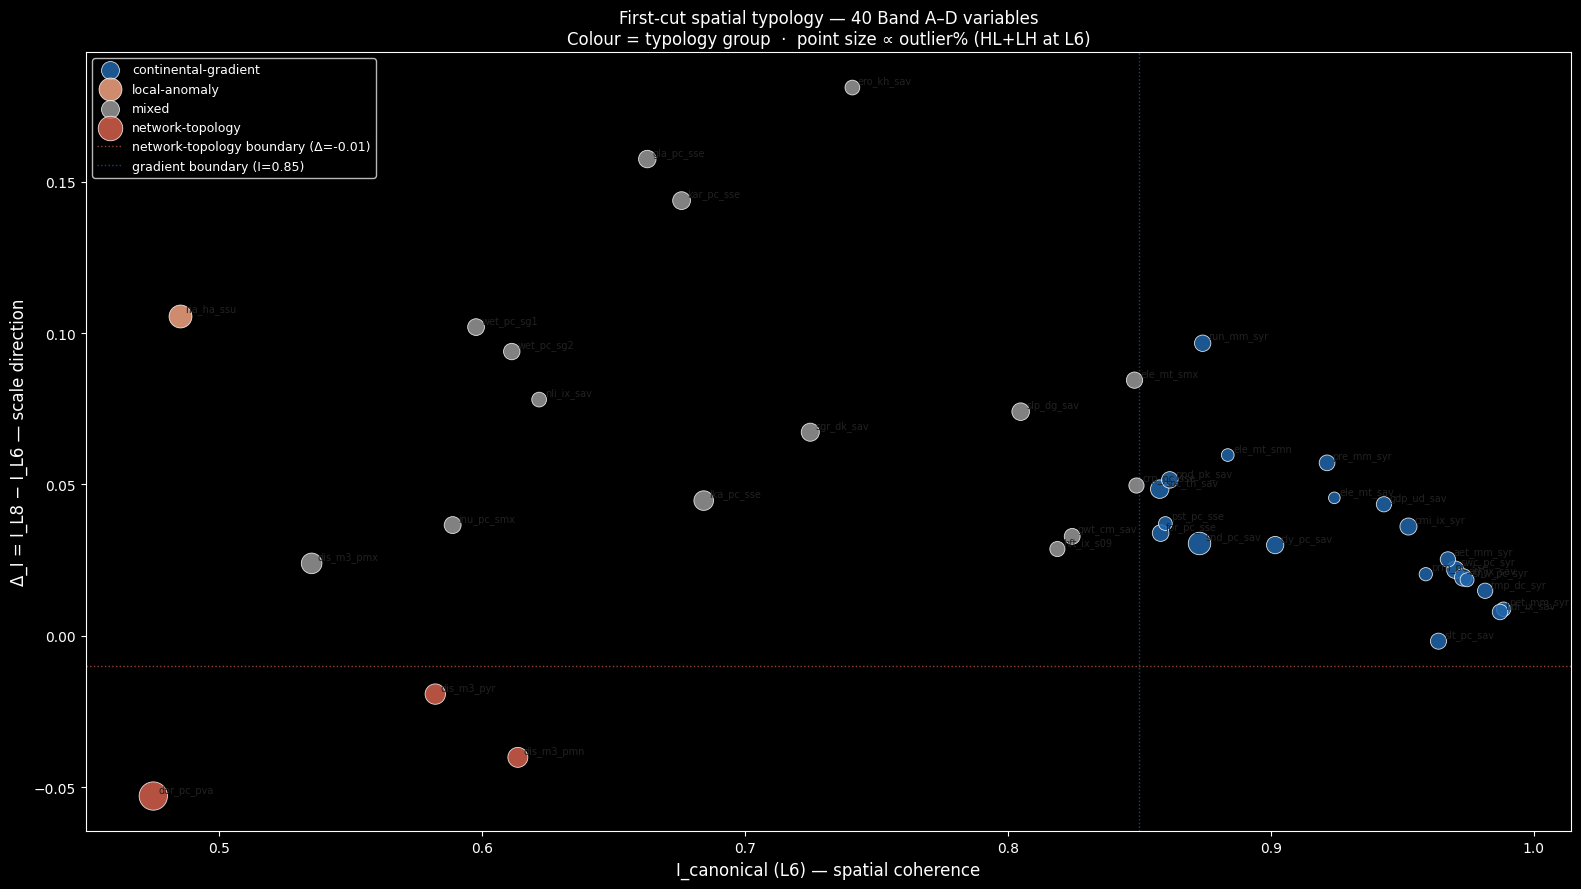

In [11]:
# Cell 10
# Profile space coloured by typology group
fig, ax = plt.subplots(figsize=(16, 9))

for group, grp in df.groupby('group'):
    sizes = 60 + grp['outlier_pct_L6'] * 60
    ax.scatter(
        grp['I_L6'], grp['delta_I'],
        s=sizes, c=GROUP_COLOURS[group], alpha=0.85,
        edgecolors='white', linewidths=0.6,
        label=group, zorder=3
    )

for var, row in df.iterrows():
    ax.annotate(
        var,
        xy=(row['I_L6'], row['delta_I']),
        xytext=(4, 3), textcoords='offset points',
        fontsize=LABEL_FONT, color='#222222'
    )

# Threshold reference lines
ax.axhline(DELTA_NEG, color='#d6604d', linewidth=1.0, linestyle=':', alpha=0.7,
           label=f'network-topology boundary (Δ={DELTA_NEG})')
ax.axvline(I_HIGH,    color='#2166ac', linewidth=1.0, linestyle=':', alpha=0.7,
           label=f'gradient boundary (I={I_HIGH})')
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)

ax.set_xlabel("I_canonical (L6) — spatial coherence", fontsize=12)
ax.set_ylabel("Δ_I = I_L8 − I_L6 — scale direction", fontsize=12)
ax.set_title(
    "First-cut spatial typology — 40 Band A–D variables\n"
    "Colour = typology group  ·  point size ∝ outlier% (HL+LH at L6)",
    fontsize=12
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(REPO / 'spatial' / 'typology_groups.png', dpi=150, bbox_inches='tight')
print('Saved → spatial/typology_groups.png')

In [12]:
# Cell 11
# Save typology CSV
out_cols = [
    'schema_key', 'friendly_name', 'band', 'group', 'boundary_flag',
    'I_L6', 'I_L8', 'delta_I', 'scale_dir', 'log_transformed',
    'cluster_core_L6', 'outlier_pct_L6', 'pct_HH_L6', 'pct_LL_L6',
    'pct_HL_L6', 'pct_LH_L6', 'LL_fraction',
    'cluster_core_L8', 'outlier_pct_L8',
    'skewness_L6', 'missing_pct_L6',
]
df[out_cols].to_csv(CSV_OUT)
print(f'Saved → {CSV_OUT}')
print(f'\nGroup counts:')
print(df['group'].value_counts().to_string())

Saved → /Users/karlg/Documents/repos/_cedop/spatial/first_cut_typology.csv

Group counts:
group
continental-gradient    21
mixed                   15
network-topology         3
local-anomaly            1


## Summary findings

*Fill in after running — update esda_findings.md with TYP.1–TYP.N entries.*

Key questions to address:
- Which variables resist clean assignment (large `mixed` group)? Why?
- Does the `mixed` group have internal structure worth splitting?
- Do the boundary-flagged variables need manual reassignment?
- Does the LL_fraction axis reveal anything within continental-gradient (e.g., arid-dominant vs. wet-dominant)?